In [1]:
from pathlib import Path

from spikeinterface.preprocessing import detect_bad_channels
import spikeinterface.full as si
from probeinterface.plotting import plot_probe
from probeinterface import Probe
import figpack.views as vv
# from hs_detection import HSDetection
from spikeinterface.preprocessing import get_motion_parameters_preset, get_motion_presets


import numpy as np
from matplotlib import pyplot as plt

(<matplotlib.collections.PolyCollection at 0x2463d8e6ae0>,
 <matplotlib.collections.PolyCollection at 0x2463d8e7da0>)

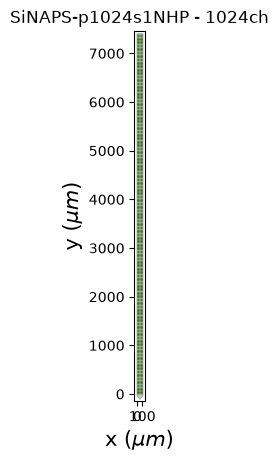

In [ ]:
def get_SiNAPS_Probe():
    # Keep this hand-written geometry for now.
    # Reference metadata also exists at:
    #   session_dir / "SiNAPS_v_1_6_kilosortChanMap.prb"
    # That .prb file describes a 1024-channel, 4 column x 256 row, 30 um channel map.
    # This notebook's hand-written geometry uses 29 um, so confirm the intended geometry before replacing it.
    # a grid 256 rows x 4 columns, 30 um apart
    positions = 29 * np.mgrid[0:256, 0:4].reshape((2, -1))[::-1].T

    probe_2d = Probe(ndim=2, si_units='um', name='SiNAPS-p1024s1NHP')
    channel_indices = np.arange(1024)
    probe_2d.set_contacts(positions=positions, shapes='square', shape_params={'width': 14}, contact_ids=channel_indices)
    probe_2d.set_device_channel_indices(channel_indices)
    probe_2d.create_auto_shape(probe_type='tip')
    return probe_2d

probe = get_SiNAPS_Probe()
plot_probe(probe)

In [76]:
from spikeinterface.core import BinaryRecordingExtractor
# from probeinterface import get_probe

repo_root = Path(r"E:\SPI hackathon")
session_dir = repo_root / "src" / "spikeinterface" / "Datasets" / "30Connell_0"
dat_path = session_dir / "30Connell_0.dat"
prb_path = session_dir / "SiNAPS_v_1_6_kilosortChanMap.prb"

# The .prb path is kept as reference metadata only; do not replace the hand-written probe geometry here.

recording = BinaryRecordingExtractor(
    file_paths=dat_path,
    sampling_frequency=20000.0,
    num_channels=1024,
    dtype="int16",
    gain_to_uV=5.85,
    offset_to_uV=1.5*100
)
recording = recording.set_probe(probe)
print(recording)


BinaryRecordingExtractor: 1024 channels - 20.0kHz - 1 segments - 31,912,000 samples 
                          1,595.60s (26.59 minutes) - int16 dtype - 60.87 GiB
  file_paths: ['/disk/data/SiNAPs/30Connell_0/30Connell_0.dat']


In [57]:
recording = recording.astype('float32')

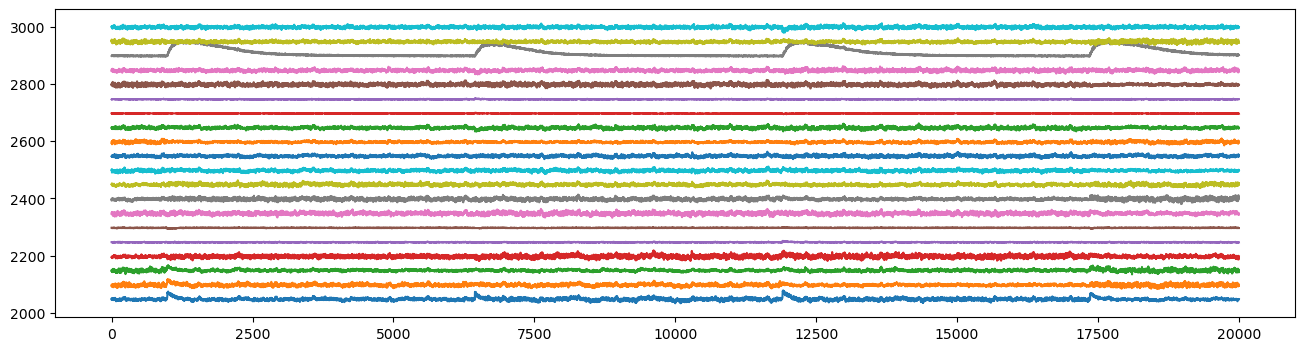

In [89]:
time_range = [0, 1]
channels = np.arange(0, 1000, 50)
# si.plot_traces(recording, channel_ids=channels, time_range=time_range,  figsize=(16, 2))
d = recording.get_traces(channel_ids=channels, start_frame=int(time_range[0] * recording.get_sampling_frequency()), end_frame=int(time_range[1] * recording.get_sampling_frequency()))
plt.figure(figsize=(16, 4))
for i in range(d.shape[1]):
    plt.plot(d[:,i] + i*50 )  # Offset each channel for better visibility
# plt.plot(d);

In [80]:
bad_channel_ids, channel_labels = si.detect_bad_channels(recording, method='std', std_mad_threshold=2, dead_channel_threshold=-1)

In [83]:
bad_channel_ids
channel_labels

array(['good', 'good', 'good', ..., 'good', 'good', 'good'],
      shape=(1024,), dtype='<U5')

/tmp/ipykernel_244892/2998763700.py:1: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  si.plot_traces(recording, channel_ids=[110,111], time_range=[0,1],  figsize=(16, 2), return_scaled=False)


/tmp/ipykernel_244892/2998763700.py:1: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  si.plot_traces(recording, channel_ids=[110,111], time_range=[0,1],  figsize=(16, 2), return_scaled=False)


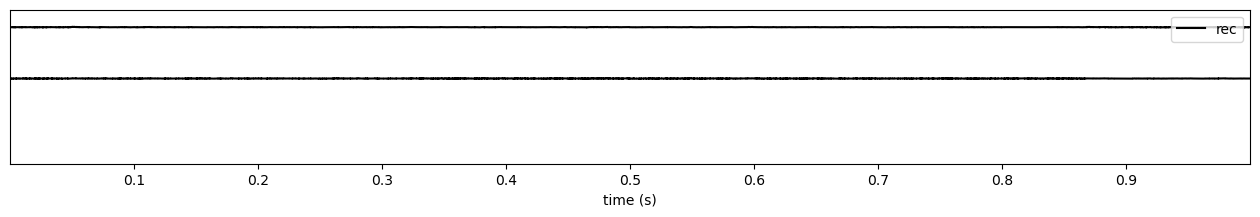

In [71]:
si.plot_traces(recording, channel_ids=[110,111], time_range=[0,1],  figsize=(16, 2), return_scaled=False)

In [86]:
recording_bandpass = si.bandpass_filter(recording, freq_min=300.0, freq_max=6000.0)

noise_random_slices = dict(num_chunks_per_segment=20, chunk_duration="500ms")
noise_seeds = range(8)
noise_estimates = np.stack([
    si.get_noise_levels(
        recording_bandpass,
        return_in_uV=False,
        force_recompute=True,
        random_slices_kwargs={**noise_random_slices, "seed": seed},
    )
    for seed in noise_seeds
])
zero_noise_mask = np.any((noise_estimates <= 0) | ~np.isfinite(noise_estimates), axis=0)
zero_noise_channel_ids = recording_bandpass.channel_ids[zero_noise_mask]
print("zero-noise channel ids:", zero_noise_channel_ids)

if len(zero_noise_channel_ids):
    recording_bandpass_for_motion = recording_bandpass.remove_channels(zero_noise_channel_ids)
else:
    recording_bandpass_for_motion = recording_bandpass

motion_noise_estimates = np.stack([
    si.get_noise_levels(
        recording_bandpass_for_motion,
        return_in_uV=False,
        force_recompute=True,
        random_slices_kwargs={**noise_random_slices, "seed": seed},
    )
    for seed in noise_seeds
])
remaining_zero_noise_mask = np.any((motion_noise_estimates <= 0) | ~np.isfinite(motion_noise_estimates), axis=0)
assert not np.any(remaining_zero_noise_mask), recording_bandpass_for_motion.channel_ids[remaining_zero_noise_mask]
recording_bandpass_for_motion.set_property("noise_level_mad_raw", np.mean(motion_noise_estimates, axis=0))

In [88]:
preset = "dredge"
folder = "./motion_tmp/"
motion, motion_info = si.compute_motion(
        recording_bandpass_for_motion, preset=preset, folder=folder, output_motion_info=True
    )

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

ZeroDivisionError: division by zero